# Data Understanding

## Data Collection

Langkah pertama dalam proyek ini adalah mengumpulkan data polutan udara (seperti NO₂, CO, dan SO₂) yang bertipe deret waktu (*Time Series*). Dataset ini diambil dari platform satelit [Copernicus Data Space Ecosystem](https://dataspace.copernicus.eu/).

Buat akun terlebih dahulu di website Copernicus agar bisa melakukan crawling data menggunakan library openEO.

## Install Library

Untuk melakukan proses crawling data, kita membutuhkan pustaka Python pendukung yaitu `openeo` untuk berkomunikasi dengan API Copernicus, dan `netCDF4` untuk membaca format data cuaca spasial (`.nc`).

```bash
pip install openeo
pip install netCDF4
```

## Autentikasi dan Pengambilan Data

Skrip di bawah ini melakukan proses autentikasi untuk menghubungkan sistem lokal kita dengan server Copernicus menggunakan _device code flow_.

```python
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
```

Saat menjalankan baris di atas, akan muncul permintaan autentikasi:

```
Visit (link authentikasi) 📋 to authenticate.
✅ Authorized successfully
Authenticated using device code flow.
```

Klik link autentikasi lalu login menggunakan akun Copernicus.

## Definisi Area dan Pengambilan Data NO₂, CO dan SO₂ dari geojson

Setelah berhasil masuk, langkah selanjutnya adalah menentukan wilayah spesifik. Titik koordinat wilayah Nunukan (Poligon) didapatkan menggunakan alat bantu pemetaan [geojson.io](https://geojson.io) dengan menggambar kotak di atas wilayah yang diinginkan kemudian menyalin koordinatnya.

![Grafik Data](geojson.png)

Koordinat yang didapatkan dimasukkan ke dalam variabel aoi (Area of Interest). Satelit Sentinel-5P kemudian diminta untuk mengambil data polutan berdasarkan bounding box wilayah tersebut dengan menyesuaikan variabel s5post atribut bands.

Karena satelit mungkin merekam area yang sama beberapa kali, dilakukan agregasi temporal harian agar hanya terdapat rata-rata satu data per hari. Dilanjutkan dengan agregasi spasial agar seluruh grid pada wilayah Nganjuk dirata-rata menjadi satu nilai tunggal.

```
aoi = {
    "type": "Polygon",
    # Paste koordinat yang didapat 
    "coordinates":
        [
            [
              117.58812764552601,
              4.133326974398287
            ],
            [
              117.75161907303544,
              4.133326974398287
            ],
            [
              117.75161907303544,
              3.971832859595736
            ],
            [
              117.58812764552601,
              3.971832859595736
            ],
            [
              117.58812764552601,
              4.133326974398287
            ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-10-01", "2026-06-01"],
    spatial_extent={
        "west": 117.58812764552601,
        "south": 3.971832859595736,
        "east": 117.75161907303544,
        "north": 4.133326974398287
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["SO2"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)
```
## Eksekusi Job dan Download

Proses agregasi data spasial ini membutuhkan waktu sehingga dikirim sebagai “Batch Job”.
```
job = s5post.execute_batch(title="NO2 in Nunukan", outputfile="NO2DiNunukan.nc")
```

Tunggu proses selesai. Status dan progres eksekusi bisa dipantau di openEO editor. Setelah diproses oleh server, output akan otomatis diunduh berupa file NetCDF NO2DiNunukan.nc.

```
0:00:00 Job 'j-26082816305840dfb06d9ac4e7a7f81e': send 'start'
0:00:03 Job 'j-26082816305840dfb06d9ac4e7a7f81e': queued (progress 0%)
0:00:08 Job 'j-26082816305840dfb06d9ac4e7a7f81e': queued (progress 0%)
0:00:15 Job 'j-26082816305840dfb06d9ac4e7a7f81e': queued (progress 0%)
0:00:23 Job 'j-26082816305840dfb06d9ac4e7a7f81e': queued (progress 0%)
0:00:33 Job 'j-26082816305840dfb06d9ac4e7a7f81e': queued (progress 0%)
0:00:46 Job 'j-26082816305840dfb06d9ac4e7a7f81e': queued (progress 0%)
0:01:01 Job 'j-26082816305840dfb06d9ac4e7a7f81e': queued (progress 0%)
0:01:21 Job 'j-26082816305840dfb06d9ac4e7a7f81e': running (progress N/A)
0:01:45 Job 'j-26082816305840dfb06d9ac4e7a7f81e': running (progress N/A)
0:02:15 Job 'j-26082816305840dfb06d9ac4e7a7f81e': running (progress N/A)
0:02:53 Job 'j-26082816305840dfb06d9ac4e7a7f81e': running (progress N/A)
0:03:40 Job 'j-26082816305840dfb06d9ac4e7a7f81e': finished (progress 100%)
```

## Simpan Data dalam Bentuk CSV
Format mentah NetCDF (.nc) yang kita dapatkan masih berbentuk matriks spasial tiga dimensi yang kurang ramah untuk dianalisis secara tabular. Oleh karena itu, kita membedah file tersebut menggunakan Python untuk di-convert ke dalam .csv:
* **Data waktu (Time) dikonversi menjadi format tanggal yang bisa dibaca.
* **Untuk mengatasi potensi adanya nilai kosong (null) di grid spasial tertentu, digunakan metode Interpolasi Linier.
* **Setelah data dibersihkan, seluruh grid Nganjuk dirata-rata untuk setiap harinya lalu disimpan ke dalam format tabel (CSV) agar mudah diproses.

```
import numpy as np
import pandas as pd
import netCDF4

file_path = "NO2DiNunukan.nc"
ds = netCDF4.Dataset(file_path)
# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

        
new_dates = []
new_no2 = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2[i]))

df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

# Simpan ke CSV
df.to_csv("NO2_Nunukan_timeseries.csv", index=False)
```
## Hasil CSV

Pada tahap terakhir, kita memuat file CSV (CO, SO₂, dan NO₂) yang telah dirapikan menggunakan pustaka Pandas. Data ini sekarang sudah terstruktur sebagai dataset Time Series dan siap digunakan untuk analisis lanjutan. Berikut adalah cuplikan data tersebut:
1. CO

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("CO_Nunukan_timeseries.csv")
df.head(5)

,date,CO
0,2025-10-01,0.026495
1,2025-10-02,0.023209
2,2025-10-03,0.027056
3,2025-10-04,NaN
4,2025-10-05,0.023067


2. SO2

In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("SO2_Nunukan_timeseries.csv")
df.head(5)

,date,SO2
0,2025-10-01,-0.000032
1,2025-10-02,0.000042
2,2025-10-03,0.000003
3,2025-10-04,NaN
4,2025-10-05,0.000012


3. NO2

In [3]:
import pandas as pd
import numpy as np
df = pd.read_csv("NO2_Nunukan_timeseries.csv")
df.head(5)

,date,NO2
0,2025-10-01,5.308143e-06
1,2025-10-02,7.622299e-06
2,2025-10-03,6.820240e-06
3,2025-10-04,NaN
4,2025-10-05,4.440758e-07


### Data Yang Hilang

Selain urutan tanggal, kita juga mengecek jumlah baris data yang memiliki nilai konsentrasi polutan kosong (`NaN`).

1. CO

In [4]:
df = pd.read_csv("CO_Nunukan_Timeseries.csv")
missing_value = df['CO'].isna().sum()
print(missing_value)

118


2. SO₂

In [5]:
df = pd.read_csv("SO2_Nunukan_Timeseries.csv")
missing_value = df['SO2'].isna().sum()
print(missing_value)

44


3. NO₂

In [6]:
df = pd.read_csv("NO2_Nunukan_Timeseries.csv")
missing_value = df['NO2'].isna().sum()
print(missing_value)

87


## Outliers

_Outliers_ (pencilan) adalah titik data yang nilainya menyimpang secara drastis atau ekstrem dari mayoritas distribusi data lainnya. Pada data deret waktu kualitas udara, _outlier_ bisa jadi merupakan lonjakan polusi nyata yang terjadi akibat peristiwa tertentu (misalnya kebakaran hutan atau peningkatan aktivitas industri mendadak), atau bisa juga sekadar _noise_ / _error_ pada pembacaan sensor satelit.

Pada tahap _data understanding_ ini, kita mengeksplorasi _outliers_ menggunakan algoritma **Isolation Forest** dari pustaka `scikit-learn`. Algoritma deteksi anomali ini bekerja dengan cara "mengisolasi" observasi melalui pemisahan data secara acak, di mana anomali akan lebih cepat/mudah diisolasi. Kita mengatur parameter _contamination_ (estimasi persentase _outlier_ di dalam dataset) sebesar 5%. Hasil prediksi dari model yang bernilai `-1` menandakan bahwa baris tersebut terdeteksi sebagai _outlier_.

1. CO

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("CO_Nunukan_Timeseries.csv")
df_clean = df.dropna(subset=['CO']).copy()

df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values('date').reset_index(drop=True)

model = IsolationForest(contamination=0.05, random_state=42)  # contamination 0.05 = 5%
pred = model.fit_predict(df_clean[['CO']])

# Tambahkan hasil prediksi ke dataframe
df_clean['anomaly'] = pred  # -1 = outlier, 1 = normal

# Nilai -1 merepresentasikan outlier
outliers_if = df_clean[df_clean['anomaly'] == -1]
jumlah_outlier = len(outliers_if)
print("Jumlah outlier:", jumlah_outlier)
print(outliers_if[['date', 'CO']].head())

Jumlah outlier: 7
         date        CO
6  2025-10-12  0.022047
65 2026-02-23  0.020537
69 2026-03-13  0.034267
70 2026-03-14  0.035311
76 2026-03-22  0.034897


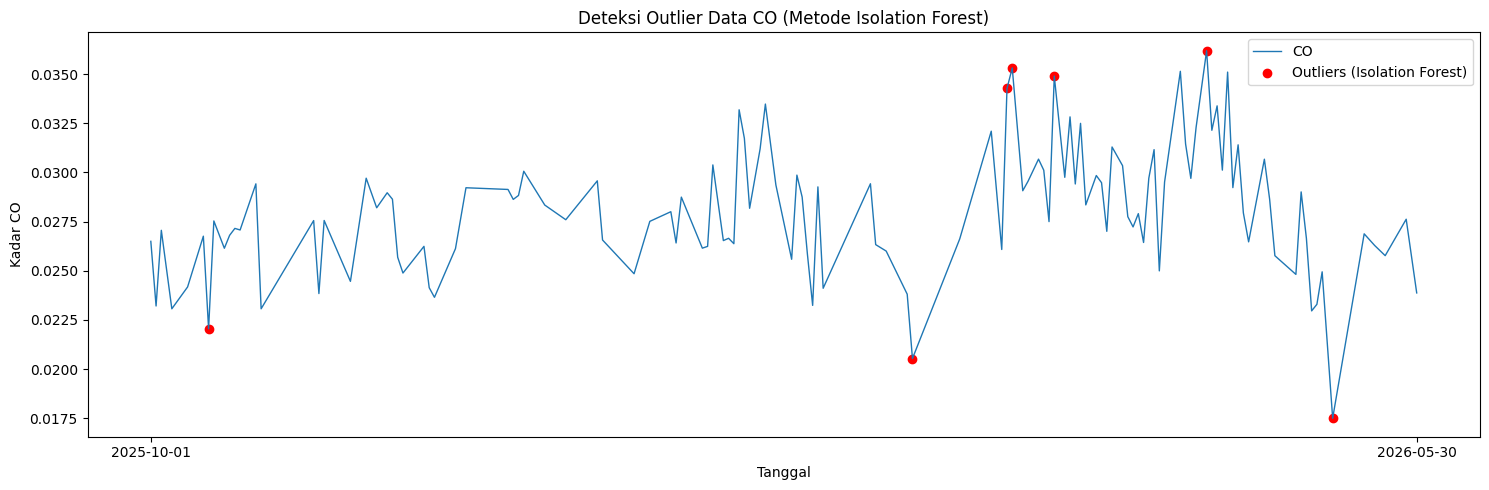

In [8]:
# Visualisasi
plt.figure(figsize=(15, 5))
plt.plot(df_clean['date'], df_clean['CO'], label="CO", linewidth=1)
plt.scatter(outliers_if['date'], outliers_if['CO'],
            color='red', marker='o', label="Outliers (Isolation Forest)")
plt.title("Deteksi Outlier Data CO (Metode Isolation Forest)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df_clean['date'].iloc[0], df_clean['date'].iloc[-1]],
    labels=[df_clean['date'].iloc[0].strftime('%Y-%m-%d'),
            df_clean['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

2. SO₂

In [9]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv("SO2_Nunukan_Timeseries.csv")
df_clean = df.dropna(subset=['SO2']).copy()

df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values('date').reset_index(drop=True)

model = IsolationForest(contamination=0.05, random_state=42)  # contamination 0.05 = 5%
pred = model.fit_predict(df_clean[['SO2']])

# Tambahkan hasil prediksi ke dataframe
df_clean['anomaly'] = pred  # -1 = outlier, 1 = normal

# Nilai -1 merepresentasikan outlier
outliers_if = df_clean[df_clean['anomaly'] == -1]
jumlah_outlier = len(outliers_if)
print("Jumlah outlier:", jumlah_outlier)
print(outliers_if[['date', 'SO2']].head())

Jumlah outlier: 10
         date       SO2
14 2025-10-20  0.000162
20 2025-10-28  0.000190
58 2025-12-15 -0.000138
64 2025-12-23  0.000426
68 2025-12-27 -0.000123


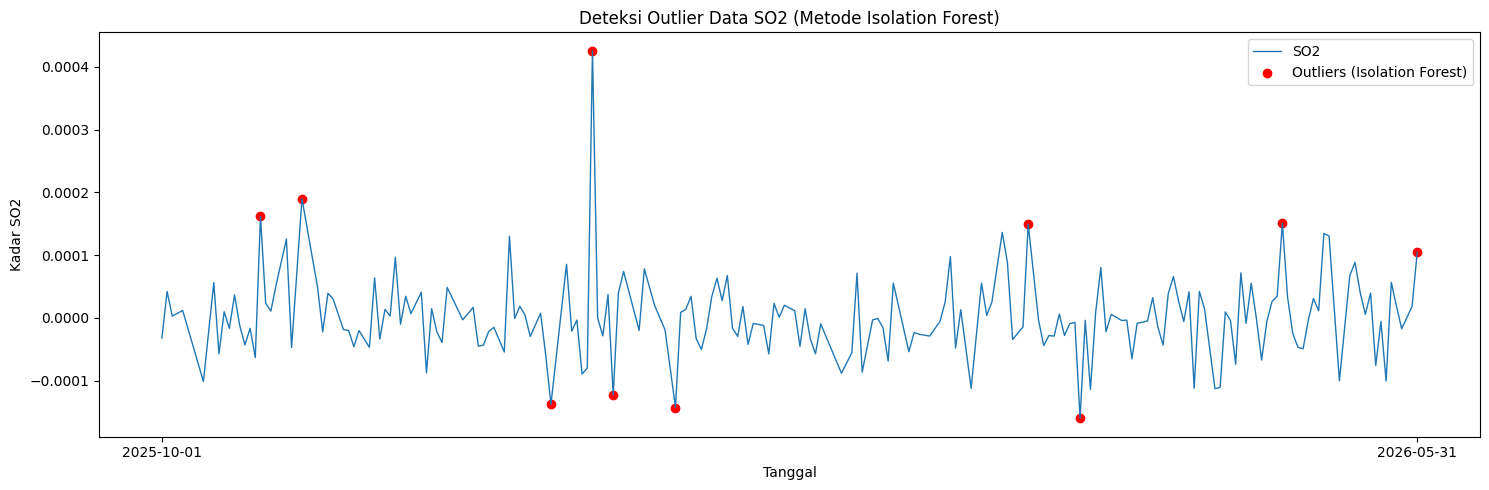

In [10]:
# Visualisasi
plt.figure(figsize=(15, 5))
plt.plot(df_clean['date'], df_clean['SO2'], label="SO2", linewidth=1)
plt.scatter(outliers_if['date'], outliers_if['SO2'],
            color='red', marker='o', label="Outliers (Isolation Forest)")
plt.title("Deteksi Outlier Data SO2 (Metode Isolation Forest)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df_clean['date'].iloc[0], df_clean['date'].iloc[-1]],
    labels=[df_clean['date'].iloc[0].strftime('%Y-%m-%d'),
            df_clean['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

3. NO₂

In [11]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv("NO2_Nunukan_Timeseries.csv")
df_clean = df.dropna(subset=['NO2']).copy()
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values('date').reset_index(drop=True)

model = IsolationForest(contamination=0.05, random_state=42)  # contamination 0.05 = 5%
pred = model.fit_predict(df_clean[['NO2']])

# Tambahkan hasil prediksi ke dataframe
df_clean['anomaly'] = pred  # -1 = outlier, 1 = normal

# Nilai -1 merepresentasikan outlier
outliers_if = df_clean[df_clean['anomaly'] == -1]
jumlah_outlier = len(outliers_if)
print("Jumlah outlier:", jumlah_outlier)
print(outliers_if[['date', 'NO2']].head())

Jumlah outlier: 8
         date       NO2
14 2025-10-20 -0.000007
20 2025-11-02  0.000017
33 2025-11-21 -0.000016
43 2025-12-07 -0.000004
90 2026-03-06  0.000019


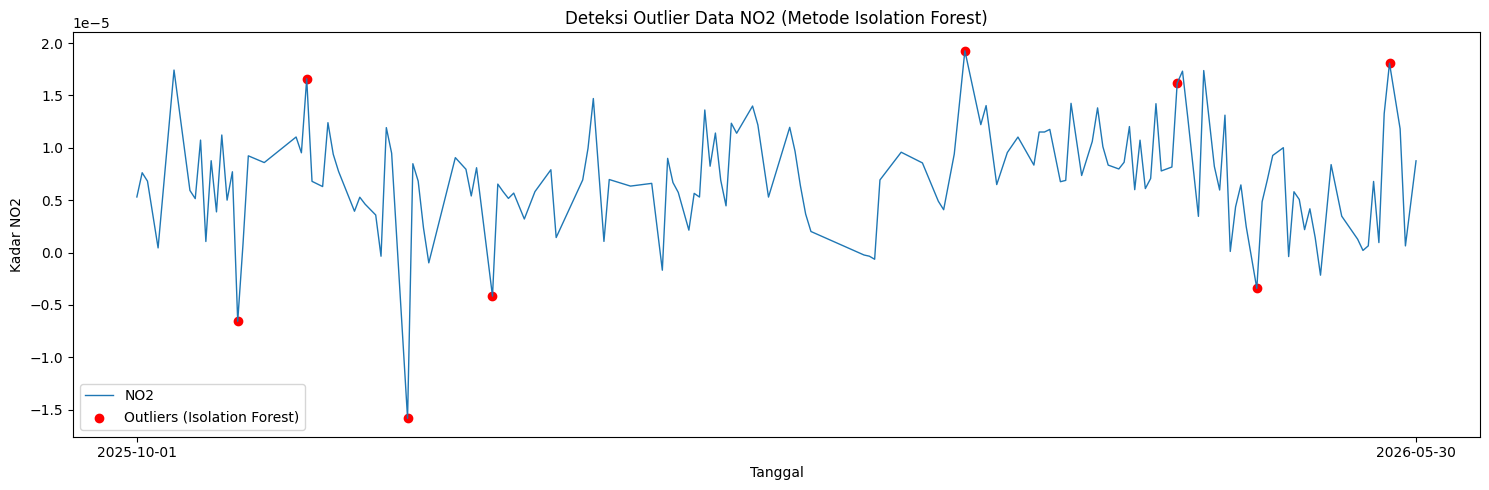

In [12]:
# Visualisasi
plt.figure(figsize=(15, 5))
plt.plot(df_clean['date'], df_clean['NO2'], label="NO2", linewidth=1)
plt.scatter(outliers_if['date'], outliers_if['NO2'],
            color='red', marker='o', label="Outliers (Isolation Forest)")
plt.title("Deteksi Outlier Data NO2 (Metode Isolation Forest)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df_clean['date'].iloc[0], df_clean['date'].iloc[-1]],
    labels=[df_clean['date'].iloc[0].strftime('%Y-%m-%d'),
            df_clean['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

## Menggabungkan File CSV

Setelah setiap dataset polutan (CO, NO₂, dan SO₂) dinormalisasi dan dianalisis nilai kosong serta pencilan (outliers)-nya, langkah selanjutnya adalah menggabungkan keempat file tersebut menjadi satu dataset terpadu. Karena keempat data tersebut direkam dengan rentang waktu harian yang sama, kita dapat menggabungkannya berdasarkan kolom tanggal (`date`). Penggabungan ini akan mempermudah proses analisis multivariat dan pemodelan pada tahap selanjutnya, karena seluruh fitur parameter polutan udara kini berada dalam satu tabel yang terpusat.

Berikut adalah kode Python menggunakan pustaka Pandas untuk menyatukan keempat dataset tersebut dan menyimpannya ke dalam file baru bernama `Polutan_Nunukan.csv`:

```python
import pandas as pd

df_co = pd.read_csv("CO_Nunukan_Timeseries.csv")
df_no2 = pd.read_csv("NO2_Nunukan_Timeseries.csv")
df_so2 = pd.read_csv("SO2_Nunukan_imeseries.csv")

dataframe_merged = pd.DataFrame({
    "date": df_o3['date'],
    "CO": df_co['CO'],
    "NO2": df_no2['NO2'],
    "SO2": df_so2['SO2']
})

dataframe_merged.to_csv("Polutan_Nunukan.csv", index=False)
```

In [13]:
df = pd.read_csv("Polutan_Nunukan.csv")
df.head(5)

,date,CO,NO2,SO2
0,2025-10-01,0.026495,5.308143e-06,-0.000032
1,2025-10-02,0.023209,7.622299e-06,0.000042
2,2025-10-03,0.027056,6.820240e-06,0.000003
3,2025-10-04,NaN,NaN,NaN
4,2025-10-05,0.023067,4.440758e-07,0.000012
